In [1]:
import os
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from torchinfo import summary
import torch

from Model import SuperResolution, TestDataset, reconstruct_rgb_from_ycbcr, calculate_psnr, calculate_ssim

In [2]:
def analyze_dataset(dataset_dir, dataset_name="Dataset"):
    """
    Analyze image dataset and print statistics.

    Args:
        dataset_dir: Path to the dataset directory
        dataset_name: Name of the dataset for display

    Returns:
        dict: Dictionary containing statistics (num_images, avg_width, avg_height, image_sizes)
    """
    image_sizes = []

    image_files = sorted(os.listdir(dataset_dir))

    for fname in image_files:
        path = os.path.join(dataset_dir, fname)

        # odpremo sliko
        img = cv2.imread(path)
        if img is not None:
            height, width = img.shape[:2]
            image_sizes.append((width, height))

    num_images = len(image_sizes)

    widths = [w for w, h in image_sizes]
    heights = [h for w, h in image_sizes]

    min_width = np.min(widths)
    max_width = np.max(widths)
    min_height = np.min(heights)
    max_height = np.max(heights)

    avg_width = np.mean(widths)
    std_width = np.std(widths)
    avg_height = np.mean(heights)
    std_height = np.std(heights)

    print(f"Dataset: {dataset_name}")
    print(f"Število slik:          {num_images}")
    print(f"Interval širine slik:  [{min_width}, {max_width}]")
    print(f"Interval višine slik:  [{min_height}, {max_height}]")
    print(f"Povprečna širina slik: {avg_width:.2f} +- {std_width:.2f}")
    print(f"Povprečna višina slik: {avg_height:.2f} +- {std_height:.2f}")
    print()

    # Prikaz 5 primerov slik iz dataseta
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    for i in range(min(5, len(image_files))):
        img_path = os.path.join(dataset_dir, image_files[i])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(image_files[i])
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

Dataset: T91
Število slik:          91
Interval širine slik:  [78, 508]
Interval višine slik:  [78, 387]
Povprečna širina slik: 264.12 +- 96.50
Povprečna višina slik: 203.58 +- 69.05



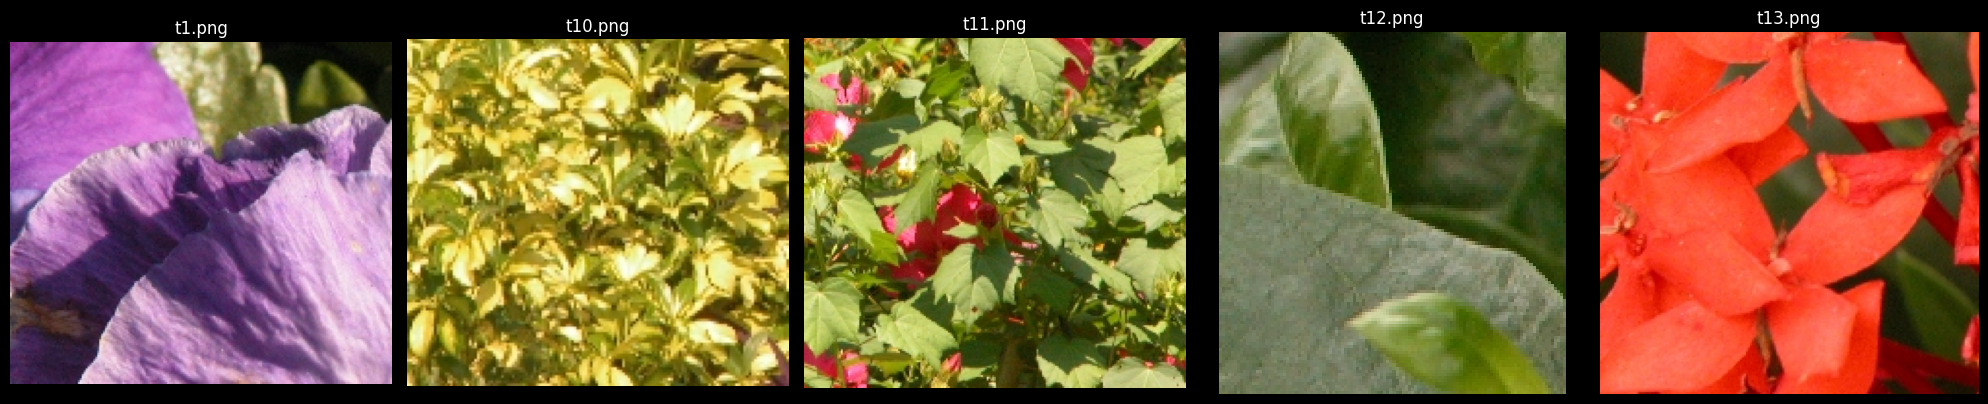

In [3]:
T91_DIR = os.path.join("datasets", "T91")

assert os.path.isdir(T91_DIR), f"Mapa {T91_DIR} ne obstaja"

analyze_dataset(T91_DIR, "T91")

Dataset: Set5
Število slik:          5
Interval širine slik:  [228, 512]
Interval višine slik:  [256, 512]
Povprečna širina slik: 312.80 +- 101.77
Povprečna višina slik: 336.00 +- 92.61



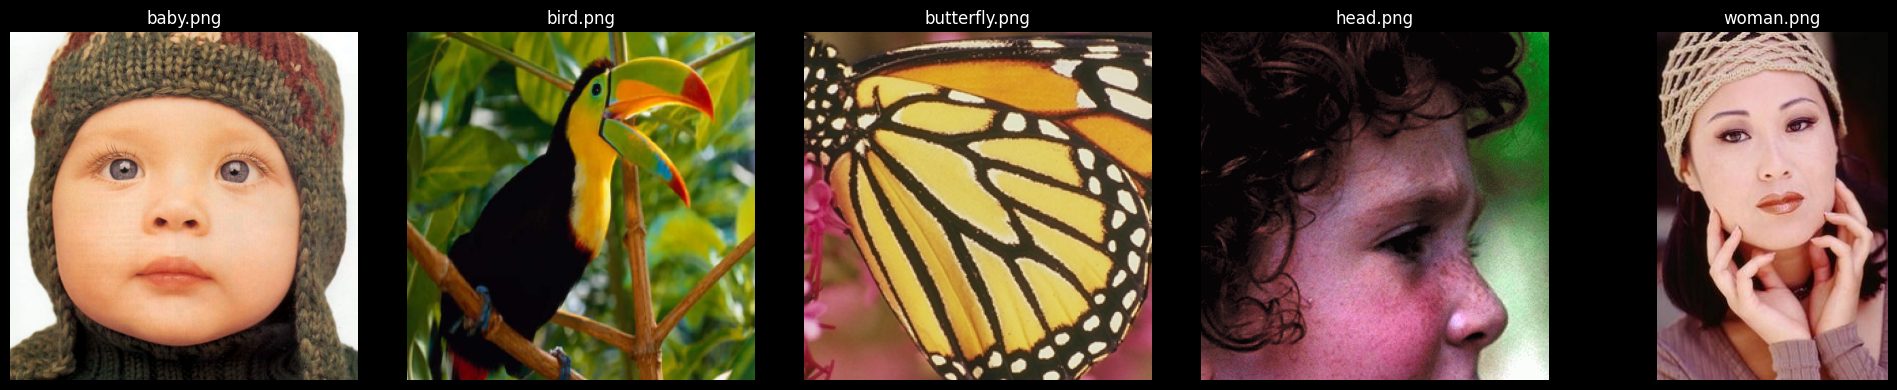

In [4]:
SET5_DIR = os.path.join("datasets", "Set5")
SET14_DIR = os.path.join("datasets", "Set14")

assert os.path.isdir(SET5_DIR), "Mapa Set5 ne obstaja"
assert os.path.isdir(SET14_DIR), "Mapa Set14 ne obstaja"

analyze_dataset(SET5_DIR, "Set5")

Dataset: Set14
Število slik:          14
Interval širine slik:  [250, 768]
Interval višine slik:  [276, 656]
Povprečna širina slik: 491.50 +- 142.56
Povprečna višina slik: 445.57 +- 113.41



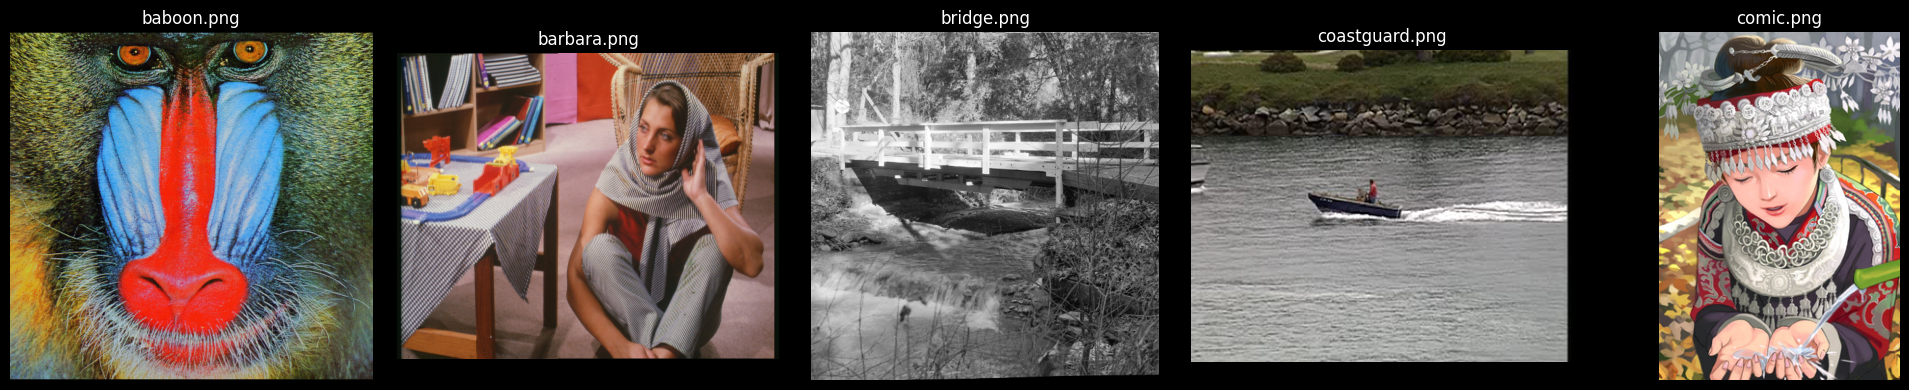

In [5]:
analyze_dataset(SET14_DIR, "Set14")

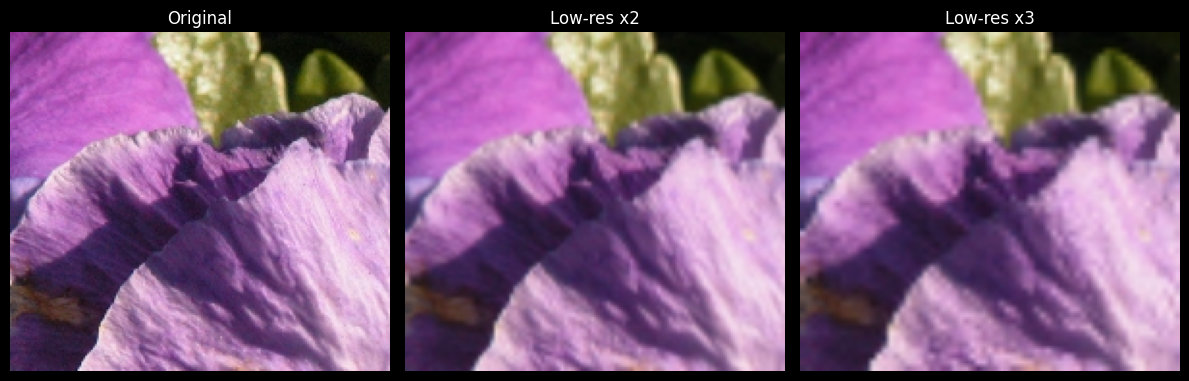

In [6]:
from Model import make_low_resolution

dataset_path = Path(T91_DIR)
image_files = list(dataset_path.glob('*.png'))

# naložimo eno testno sliko
test_img_path = str(image_files[0])  # Convert Path to string
original = cv2.imread(test_img_path)

original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

low_res_x2 = make_low_resolution(original, scale=2)
low_res_x2_rgb = cv2.cvtColor(low_res_x2, cv2.COLOR_BGR2RGB)

low_res_x3 = make_low_resolution(original, scale=3)
low_res_x3_rgb = cv2.cvtColor(low_res_x3, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(low_res_x2_rgb)
plt.title("Low-res x2")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(low_res_x3_rgb)
plt.title("Low-res x3")
plt.axis("off")

plt.tight_layout()
plt.show()

Preprocessing 91 images...
Loaded 91 images
Patches per image: 11
Total patches per epoch: 1001


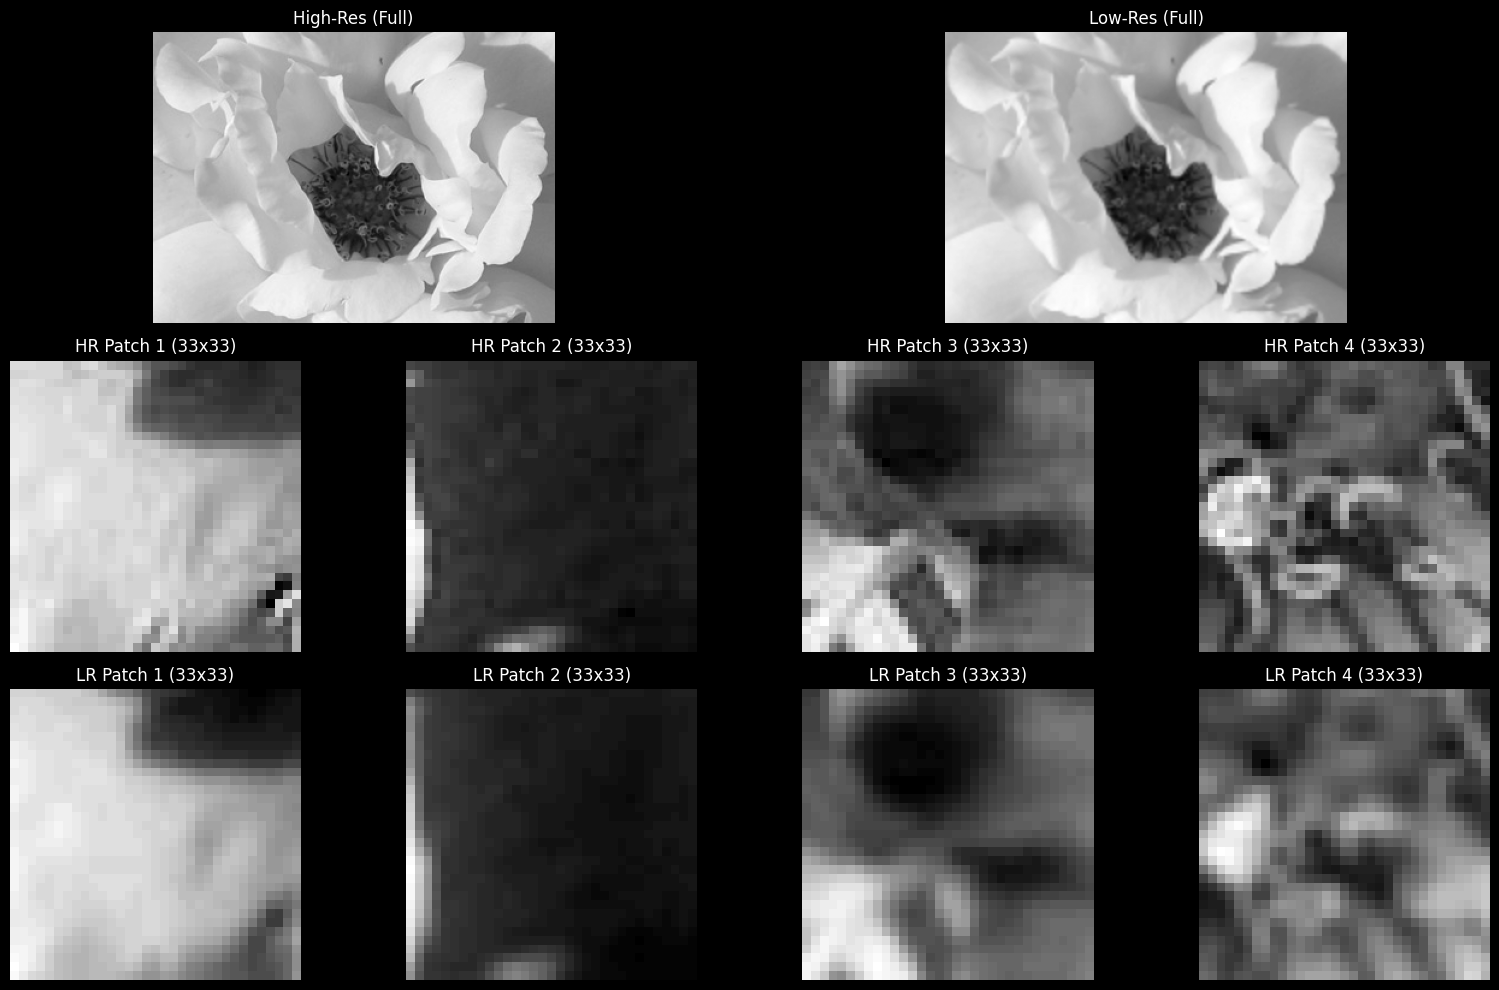

Full LR shape: (242, 334, 3)
Full HR shape: (242, 334, 3)
Patch LR shape: torch.Size([1, 33, 33])
Patch HR shape: torch.Size([1, 33, 33])


In [7]:
from Model import T91TrainDataset

dataset = T91TrainDataset(
    dataset_dir=T91_DIR,
    scale_factor=2,
    patch_size=33,
    min_patches=1000
)

# Pick any index from your dataset
idx = 42

# Get full images
lr_full, hr_full = dataset.get_original(idx)

# Get 4 random patches from the SAME image
patches = []
for _ in range(4):
    lr_patch, hr_patch = dataset[idx]
    patches.append((lr_patch, hr_patch))

# Create figure with subplots
fig = plt.figure(figsize=(16, 10))

# First row: Full images
ax1 = plt.subplot(3, 4, (1, 2))
ax1.imshow(hr_full[:, :, 0], cmap='gray')
ax1.set_title('High-Res (Full)')
ax1.axis('off')

ax2 = plt.subplot(3, 4, (3, 4))
ax2.imshow(lr_full[:, :, 0], cmap='gray')
ax2.set_title('Low-Res (Full)')
ax2.axis('off')

# Second row: High-res patches
for i in range(4):
    ax = plt.subplot(3, 4, i + 5)
    hr_patch = patches[i][1].squeeze(0).numpy()
    ax.imshow(hr_patch, cmap='gray', interpolation='none')
    ax.set_title(f'HR Patch {i + 1} ({hr_patch.shape[0]}x{hr_patch.shape[1]})')
    ax.axis('off')
    ax.set_aspect('equal')  # Keep aspect ratio

# Third row: Low-res patches
for i in range(4):
    ax = plt.subplot(3, 4, i + 9)
    lr_patch = patches[i][0].squeeze(0).numpy()
    ax.imshow(lr_patch, cmap='gray', interpolation='none')
    ax.set_title(f'LR Patch {i + 1} ({lr_patch.shape[0]}x{lr_patch.shape[1]})')
    ax.axis('off')
    ax.set_aspect('equal')  # Keep aspect ratio

plt.tight_layout()
plt.show()

print(f"Full LR shape: {lr_full.shape}")
print(f"Full HR shape: {hr_full.shape}")
print(f"Patch LR shape: {patches[0][0].shape}")
print(f"Patch HR shape: {patches[0][1].shape}")

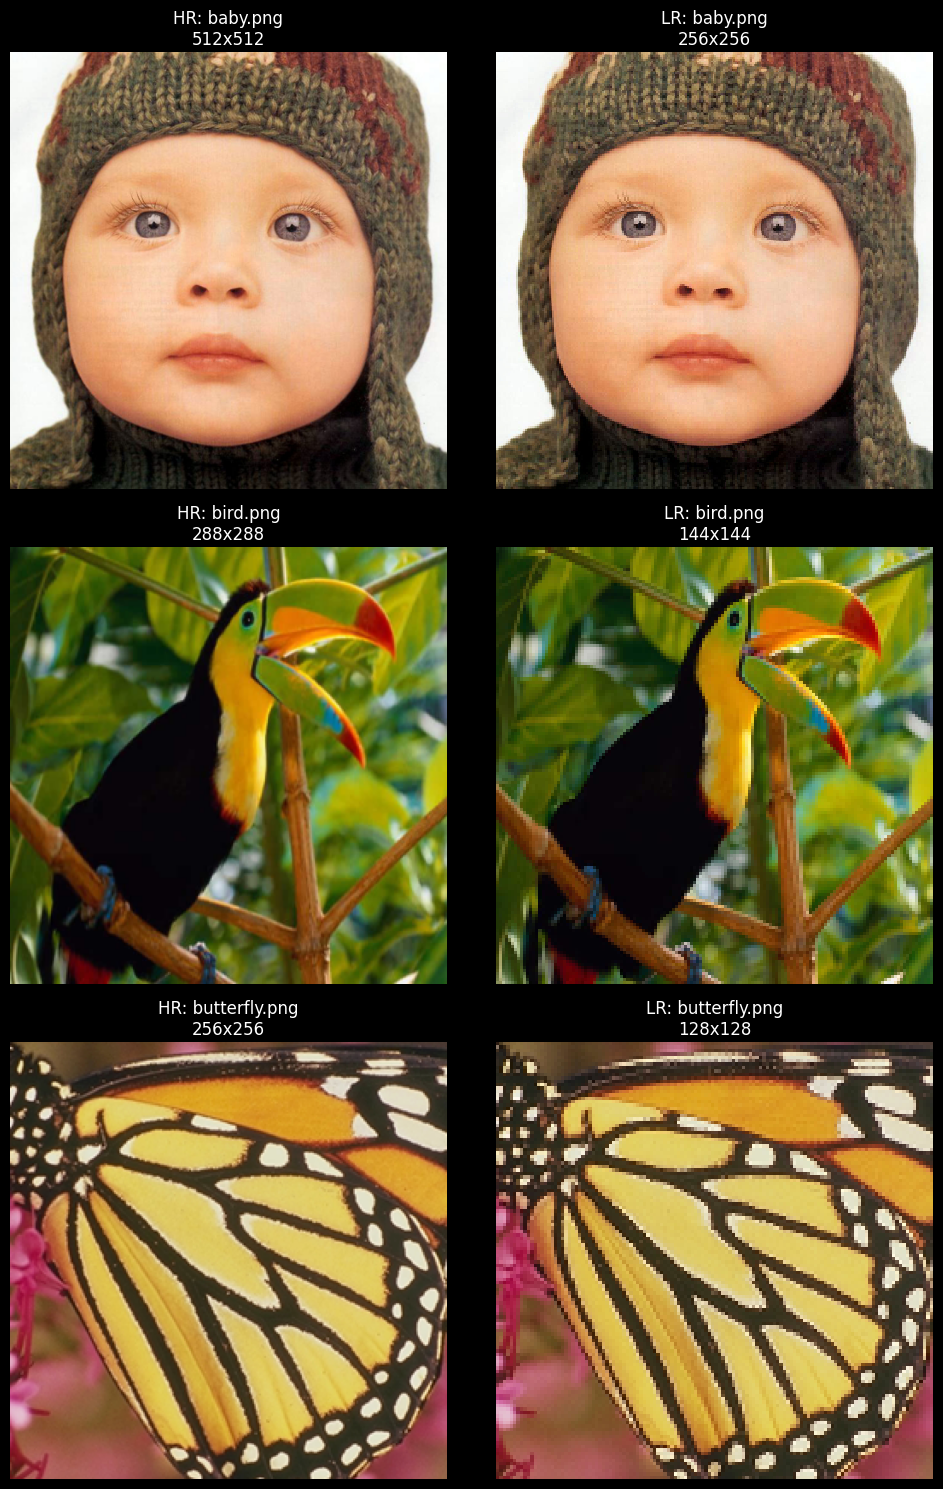

Dataset size: 5 images
LR shape: (256, 256, 3)
HR shape: (512, 512, 3)


In [8]:
from Model import TestDataset

# Load test dataset
set_dataset = TestDataset(SET5_DIR, scale_factor=2)

# Display first 3 images
num_images = min(3, len(set_dataset))
fig, axes = plt.subplots(num_images, 2, figsize=(10, 5 * num_images))

# Handle single image case
if num_images == 1:
    axes = axes.reshape(1, -1)

for i in range(num_images):
    lr_ycbcr, hr_ycbcr = set_dataset[i]
    filename = set_dataset.get_filename(i)

    # Convert YCbCr back to RGB for display
    lr_rgb = cv2.cvtColor((lr_ycbcr * 255).astype(np.uint8), cv2.COLOR_YCrCb2RGB)
    hr_rgb = cv2.cvtColor((hr_ycbcr * 255).astype(np.uint8), cv2.COLOR_YCrCb2RGB)

    # High-res image
    axes[i, 0].imshow(hr_rgb)
    axes[i, 0].set_title(f'HR: {filename}\n{hr_rgb.shape[1]}x{hr_rgb.shape[0]}')
    axes[i, 0].axis('off')

    # Low-res image
    axes[i, 1].imshow(lr_rgb, interpolation='nearest')
    axes[i, 1].set_title(f'LR: {filename}\n{lr_rgb.shape[1]}x{lr_rgb.shape[0]}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"Dataset size: {len(set_dataset)} images")
print(f"LR shape: {set_dataset[0][0].shape}")
print(f"HR shape: {set_dataset[0][1].shape}")

In [ ]:
model = SuperResolution()
summary(model, input_size=(1, 1, 33, 33))


In [ ]:
# LOAD BEST MODEL

SCALE_FACTOR = 2
checkpoint_dir = Path(f"./checkpoints_x{SCALE_FACTOR}")
best_model_path = checkpoint_dir / "best_model.pth"
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SuperResolution()
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()
print(f"✅ Best model loaded from {best_model_path}")
print(f"📍 Using device: {device}")

In [ ]:
# LOAD LATEST CHECKPOINT
from Helper import load_checkpoint_generic

SCALE_FACTOR = 2
checkpoint_dir = Path(f"./checkpoints_x{SCALE_FACTOR}")
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SuperResolution()
checkpoint = load_checkpoint_generic(str(checkpoint_dir), device)
if checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()
print("✅ Model loaded from latest checkpoint")

In [ ]:
# EVALUATE ON T91
test_t91 = TestDataset(T91_DIR, scale_factor=SCALE_FACTOR)

psnr_lr_list = []
ssim_lr_list = []
psnr_sr_list = []
ssim_sr_list = []

print("Evaluating T91...")
for idx in range(len(test_t91)):
    lr_ycbcr, hr_ycbcr = test_t91[idx]

    # Extract Y channels
    lr_y = lr_ycbcr[:, :, 0]
    hr_y = hr_ycbcr[:, :, 0]

    # Run model
    lr_y_tensor = torch.from_numpy(lr_y).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        sr_y_tensor = model(lr_y_tensor)
    sr_y = sr_y_tensor.squeeze().cpu().numpy()

    # Calculate metrics: Original vs LowRes
    psnr_lr = calculate_psnr(hr_y, lr_y)
    ssim_lr = calculate_ssim(hr_y, lr_y)

    # Calculate metrics: Original vs Predicted
    psnr_sr = calculate_psnr(hr_y, sr_y)
    ssim_sr = calculate_ssim(hr_y, sr_y)

    psnr_lr_list.append(psnr_lr)
    ssim_lr_list.append(ssim_lr)
    psnr_sr_list.append(psnr_sr)
    ssim_sr_list.append(ssim_sr)

print("\n📊 T91 Results:")
print(f"Original vs LowRes    - PSNR: {np.mean(psnr_lr_list):.2f} ± {np.std(psnr_lr_list):.2f} dB")
print(f"                      - SSIM: {np.mean(ssim_lr_list):.4f} ± {np.std(ssim_lr_list):.4f}")
print(f"Original vs Predicted - PSNR: {np.mean(psnr_sr_list):.2f} ± {np.std(psnr_sr_list):.2f} dB")
print(f"                      - SSIM: {np.mean(ssim_sr_list):.4f} ± {np.std(ssim_sr_list):.4f}")

In [ ]:
# EVALUATE ON SET5
test_set5 = TestDataset(SET5_DIR, scale_factor=SCALE_FACTOR)

psnr_lr_list = []
ssim_lr_list = []
psnr_sr_list = []
ssim_sr_list = []

print("Evaluating Set5...")
for idx in range(len(test_set5)):
    lr_ycbcr, hr_ycbcr = test_set5[idx]

    # Extract Y channels
    lr_y = lr_ycbcr[:, :, 0]
    hr_y = hr_ycbcr[:, :, 0]

    # Run model
    lr_y_tensor = torch.from_numpy(lr_y).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        sr_y_tensor = model(lr_y_tensor)
    sr_y = sr_y_tensor.squeeze().cpu().numpy()

    # Calculate metrics: Original vs LowRes
    psnr_lr = calculate_psnr(hr_y, lr_y)
    ssim_lr = calculate_ssim(hr_y, lr_y)

    # Calculate metrics: Original vs Predicted
    psnr_sr = calculate_psnr(hr_y, sr_y)
    ssim_sr = calculate_ssim(hr_y, sr_y)

    psnr_lr_list.append(psnr_lr)
    ssim_lr_list.append(ssim_lr)
    psnr_sr_list.append(psnr_sr)
    ssim_sr_list.append(ssim_sr)

print("\n📊 Set5 Results:")
print(f"Original vs LowRes    - PSNR: {np.mean(psnr_lr_list):.2f} ± {np.std(psnr_lr_list):.2f} dB")
print(f"                      - SSIM: {np.mean(ssim_lr_list):.4f} ± {np.std(ssim_lr_list):.4f}")
print(f"Original vs Predicted - PSNR: {np.mean(psnr_sr_list):.2f} ± {np.std(psnr_sr_list):.2f} dB")
print(f"                      - SSIM: {np.mean(ssim_sr_list):.4f} ± {np.std(ssim_sr_list):.4f}")

In [ ]:
# EVALUATE ON SET14
test_set14 = TestDataset(SET14_DIR, scale_factor=SCALE_FACTOR)

psnr_lr_list = []
ssim_lr_list = []
psnr_sr_list = []
ssim_sr_list = []

print("Evaluating Set14...")
for idx in range(len(test_set14)):
    lr_ycbcr, hr_ycbcr = test_set14[idx]

    # Extract Y channels
    lr_y = lr_ycbcr[:, :, 0]
    hr_y = hr_ycbcr[:, :, 0]

    # Run model
    lr_y_tensor = torch.from_numpy(lr_y).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        sr_y_tensor = model(lr_y_tensor)
    sr_y = sr_y_tensor.squeeze().cpu().numpy()

    # Calculate metrics
    psnr_lr = calculate_psnr(hr_y, lr_y)
    ssim_lr = calculate_ssim(hr_y, lr_y)
    psnr_sr = calculate_psnr(hr_y, sr_y)
    ssim_sr = calculate_ssim(hr_y, sr_y)

    psnr_lr_list.append(psnr_lr)
    ssim_lr_list.append(ssim_lr)
    psnr_sr_list.append(psnr_sr)
    ssim_sr_list.append(ssim_sr)

print("\n📊 Set14 Results:")
print(f"Original vs LowRes    - PSNR: {np.mean(psnr_lr_list):.2f} ± {np.std(psnr_lr_list):.2f} dB")
print(f"                      - SSIM: {np.mean(ssim_lr_list):.4f} ± {np.std(ssim_lr_list):.4f}")
print(f"Original vs Predicted - PSNR: {np.mean(psnr_sr_list):.2f} ± {np.std(psnr_sr_list):.2f} dB")
print(f"                      - SSIM: {np.mean(ssim_sr_list):.4f} ± {np.std(ssim_sr_list):.4f}")

In [ ]:
# VISUALIZE SET5 WITH METRICS
test_set5 = TestDataset(SET5_DIR, scale_factor=SCALE_FACTOR)

for idx in range(len(test_set5)):
    lr_ycbcr, hr_ycbcr = test_set5[idx]
    filename = test_set5.get_filename(idx)

    # Extract Y channels
    lr_y = lr_ycbcr[:, :, 0]
    hr_y = hr_ycbcr[:, :, 0]

    # Run model
    lr_y_tensor = torch.from_numpy(lr_y).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        sr_y_tensor = model(lr_y_tensor)
    sr_y = sr_y_tensor.squeeze().cpu().numpy()

    # Calculate metrics
    psnr_lr = calculate_psnr(hr_y, lr_y)
    ssim_lr = calculate_ssim(hr_y, lr_y)
    psnr_sr = calculate_psnr(hr_y, sr_y)
    ssim_sr = calculate_ssim(hr_y, sr_y)

    # Reconstruct RGB images
    sr_y_uint8 = np.clip(sr_y * 255.0, 0, 255).astype(np.uint8)
    sr_rgb = reconstruct_rgb_from_ycbcr(sr_y_uint8,
                                        (lr_ycbcr[:, :, 1] * 255).astype(np.uint8),
                                        (lr_ycbcr[:, :, 2] * 255).astype(np.uint8))
    hr_rgb = cv2.cvtColor((hr_ycbcr * 255).astype(np.uint8), cv2.COLOR_YCrCb2RGB)
    lr_rgb = cv2.cvtColor((lr_ycbcr * 255).astype(np.uint8), cv2.COLOR_YCrCb2RGB)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(hr_rgb)
    axes[0].set_title(f'Original\n{filename}')
    axes[0].axis('off')

    axes[1].imshow(lr_rgb)
    axes[1].set_title(f'Low-Res\nPSNR: {psnr_lr:.2f} dB | SSIM: {ssim_lr:.4f}')
    axes[1].axis('off')

    axes[2].imshow(sr_rgb)
    axes[2].set_title(f'Predicted\nPSNR: {psnr_sr:.2f} dB | SSIM: {ssim_sr:.4f}')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# VISUALIZE SET14 WITH METRICS
test_set14 = TestDataset(SET14_DIR, scale_factor=SCALE_FACTOR)

for idx in range(len(test_set14)):
    lr_ycbcr, hr_ycbcr = test_set14[idx]
    filename = test_set14.get_filename(idx)

    # Extract Y channels
    lr_y = lr_ycbcr[:, :, 0]
    hr_y = hr_ycbcr[:, :, 0]

    # Run model
    lr_y_tensor = torch.from_numpy(lr_y).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        sr_y_tensor = model(lr_y_tensor)
    sr_y = sr_y_tensor.squeeze().cpu().numpy()

    # Calculate metrics
    psnr_lr = calculate_psnr(hr_y, lr_y)
    ssim_lr = calculate_ssim(hr_y, lr_y)
    psnr_sr = calculate_psnr(hr_y, sr_y)
    ssim_sr = calculate_ssim(hr_y, sr_y)

    # Reconstruct RGB images
    sr_y_uint8 = np.clip(sr_y * 255.0, 0, 255).astype(np.uint8)
    sr_rgb = reconstruct_rgb_from_ycbcr(sr_y_uint8,
                                        (lr_ycbcr[:, :, 1] * 255).astype(np.uint8),
                                        (lr_ycbcr[:, :, 2] * 255).astype(np.uint8))
    hr_rgb = cv2.cvtColor((hr_ycbcr * 255).astype(np.uint8), cv2.COLOR_YCrCb2RGB)
    lr_rgb = cv2.cvtColor((lr_ycbcr * 255).astype(np.uint8), cv2.COLOR_YCrCb2RGB)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(hr_rgb)
    axes[0].set_title(f'Original\n{filename}')
    axes[0].axis('off')

    axes[1].imshow(lr_rgb)
    axes[1].set_title(f'Low-Res\nPSNR: {psnr_lr:.2f} dB | SSIM: {ssim_lr:.4f}')
    axes[1].axis('off')

    axes[2].imshow(sr_rgb)
    axes[2].set_title(f'Predicted\nPSNR: {psnr_sr:.2f} dB | SSIM: {ssim_sr:.4f}')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# SHOW DETAILED CROP FOR SPECIFIC IMAGE
# You can change the dataset and idx to examine different images
test_dataset = TestDataset(SET5_DIR, scale_factor=SCALE_FACTOR)  # Change to SET14_DIR or T91_DIR
idx = 0  # Change to see different images
crop_y, crop_x = 50, 50  # Top-left corner of crop
crop_size = 100  # Size of crop

lr_ycbcr, hr_ycbcr = test_dataset[idx]
filename = test_dataset.get_filename(idx)

# Process image
lr_y = lr_ycbcr[:, :, 0]
hr_y = hr_ycbcr[:, :, 0]
lr_y_tensor = torch.from_numpy(lr_y).unsqueeze(0).unsqueeze(0).to(device)
with torch.no_grad():
    sr_y_tensor = model(lr_y_tensor)
sr_y = sr_y_tensor.squeeze().cpu().numpy()

# Calculate metrics
psnr_lr = calculate_psnr(hr_y, lr_y)
ssim_lr = calculate_ssim(hr_y, lr_y)
psnr_sr = calculate_psnr(hr_y, sr_y)
ssim_sr = calculate_ssim(hr_y, sr_y)

# Reconstruct RGB
sr_y_uint8 = np.clip(sr_y * 255.0, 0, 255).astype(np.uint8)
sr_rgb = reconstruct_rgb_from_ycbcr(sr_y_uint8,
                                    (lr_ycbcr[:, :, 1] * 255).astype(np.uint8),
                                    (lr_ycbcr[:, :, 2] * 255).astype(np.uint8))
hr_rgb = cv2.cvtColor((hr_ycbcr * 255).astype(np.uint8), cv2.COLOR_YCrCb2RGB)
lr_rgb = cv2.cvtColor((lr_ycbcr * 255).astype(np.uint8), cv2.COLOR_YCrCb2RGB)

# Extract crops
hr_crop = hr_rgb[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size]
lr_crop = lr_rgb[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size]
sr_crop = sr_rgb[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size]

# Plot full images with crop region highlighted
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(hr_rgb)
axes[0].set_title(f'Original\n{filename}')
axes[0].add_patch(plt.Rectangle((crop_x, crop_y), crop_size, crop_size,
                                fill=False, edgecolor='red', linewidth=2))
axes[0].axis('off')

axes[1].imshow(lr_rgb)
axes[1].set_title(f'Low-Res\nPSNR: {psnr_lr:.2f} dB | SSIM: {ssim_lr:.4f}')
axes[1].add_patch(plt.Rectangle((crop_x, crop_y), crop_size, crop_size,
                                fill=False, edgecolor='red', linewidth=2))
axes[1].axis('off')

axes[2].imshow(sr_rgb)
axes[2].set_title(f'Predicted\nPSNR: {psnr_sr:.2f} dB | SSIM: {ssim_sr:.4f}')
axes[2].add_patch(plt.Rectangle((crop_x, crop_y), crop_size, crop_size,
                                fill=False, edgecolor='red', linewidth=2))
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Plot crops
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(hr_crop)
axes[0].set_title('Original (Crop)')
axes[0].axis('off')

axes[1].imshow(lr_crop)
axes[1].set_title('Low-Res (Crop)')
axes[1].axis('off')

axes[2].imshow(sr_crop)
axes[2].set_title('Predicted (Crop)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# SUMMARY TABLE OF ALL RESULTS
import pandas as pd

# Store results for each dataset
results = []

for dataset_name, dataset_dir in [("T91", T91_DIR), ("Set5", SET5_DIR), ("Set14", SET14_DIR)]:
    test_dataset = TestDataset(dataset_dir, scale_factor=SCALE_FACTOR)

    psnr_lr_list = []
    ssim_lr_list = []
    psnr_sr_list = []
    ssim_sr_list = []

    for idx in range(len(test_dataset)):
        lr_ycbcr, hr_ycbcr = test_dataset[idx]

        lr_y = lr_ycbcr[:, :, 0]
        hr_y = hr_ycbcr[:, :, 0]

        lr_y_tensor = torch.from_numpy(lr_y).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            sr_y_tensor = model(lr_y_tensor)
        sr_y = sr_y_tensor.squeeze().cpu().numpy()

        psnr_lr_list.append(calculate_psnr(hr_y, lr_y))
        ssim_lr_list.append(calculate_ssim(hr_y, lr_y))
        psnr_sr_list.append(calculate_psnr(hr_y, sr_y))
        ssim_sr_list.append(calculate_ssim(hr_y, sr_y))

    results.append({
        'Dataset': dataset_name,
        'PSNR_LR_Mean': np.mean(psnr_lr_list),
        'PSNR_LR_Std': np.std(psnr_lr_list),
        'SSIM_LR_Mean': np.mean(ssim_lr_list),
        'SSIM_LR_Std': np.std(ssim_lr_list),
        'PSNR_SR_Mean': np.mean(psnr_sr_list),
        'PSNR_SR_Std': np.std(psnr_sr_list),
        'SSIM_SR_Mean': np.mean(ssim_sr_list),
        'SSIM_SR_Std': np.std(ssim_sr_list),
    })

# Create DataFrame
df = pd.DataFrame(results)

# Display with nice formatting
print("\n" + "="*80)
print("📊 SUMMARY OF RESULTS - Super-Resolution Model")
print("="*80)
print("\nOriginal vs Low-Res:")
print("-"*80)
for _, row in df.iterrows():
    print(f"{row['Dataset']:6s} | PSNR: {row['PSNR_LR_Mean']:6.2f} ± {row['PSNR_LR_Std']:5.2f} dB | SSIM: {row['SSIM_LR_Mean']:.4f} ± {row['SSIM_LR_Std']:.4f}")

print("\nOriginal vs Predicted:")
print("-"*80)
for _, row in df.iterrows():
    print(f"{row['Dataset']:6s} | PSNR: {row['PSNR_SR_Mean']:6.2f} ± {row['PSNR_SR_Std']:5.2f} dB | SSIM: {row['SSIM_SR_Mean']:.4f} ± {row['SSIM_SR_Std']:.4f}")
print("="*80)

# Display as table
display(df)